In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# Homework 5: Detecting Breast Cancer — Classifying Tumors 🩺

### Collaborators and Sources
In addition to recording your **collaborators** (TAs, peers, group members, roommates, etc.) on this homework in the cell below, you are required to **cite/indicate all external sources** used when finishing this assignment. 
External sources are defined as anything that is not considered course material, such as online sources (webpages, blog posts, etc.), content generated by AI systems, books, etc.

When using external sources, indicate what kind of external sources (e.g. stack overflow, WashU chatGPT, etc.) you used in the cell below and then provide more specific citations (such as links to webpages or in case of AI generated asnwers the actual sources (links provided by the AI system) and the prompt used to generate the answers) with your answer to **each specific problem**.  


Note that these citations will not free you from your obligation to submit your _own_ code and write-ups, however, they will be taken into account during the grading and regrading process, **especially** when two or more submissions closely resemble each other. Working with each other is ok, as long as you cite who you worked with and you don't copy anyone's answers directly!

### Submission instructions
* Submit this Python notebook on Gradescope.
* Execute all cells and save your notebook prior to submission. 
* Don't forget to commit and push to your Github repo!
* **Do not change the number of cells!** Your submission notebook should have exactly one code cell per problem. 
* Do **not** remove the `# your code here` line. Add your solution **after** that line. 

## Let's get started

For this homework, work through **Lab 5 (Detecting Breast Cancer using Logistic Regression)** first. Many of the things we ask you to do in this homework are explained in the lab. In general, you should feel free to import any package that we have previously used in class. Ensure that all plots have the necessary components that a plot should have (e.g. axes labels, a title, a legend).

Frequently **save** your notebook!

## 1. Predicting Breast Cancer
Now, we have a pretty good understanding of logistic regression for classification. So, let's turn to our actual application for _this week_: predicting whether a patient has breast cancer or not. First, let's take a quick look at the data from the University of Wisconsin. Each data point contains information about the breast cancer cells of a single patient derived from a digitized image of a fine needle aspirate (FNA) of breast mass, similar to these: 

![fine needle aspirate](utility/pics/fna.jpg)

Note that we do not have the image data, but the features capture the cell shapes and we also have the diagnosis (either `malignant` or `benign`), which we will treat as the class label.

### Understanding the Dataset

Let's take a look at what we have.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()

First, let's explore the data.

**Do this!** In the following cell, explore and profile the data by evaluating each of the fields in data that are related to features and targets (and their shapes), as well as the general description of the dataset.
> **Hint:** you can get the fields of the data object by entering `cancer_data.` and then pressing the tab key. 

In [4]:
print(cancer_data.data)
print(cancer_data.data_module)
print(cancer_data.DESCR)
print(cancer_data.feature_names)
print(cancer_data.filename)
print(cancer_data.frame)
print(cancer_data.target)
print(cancer_data.target_names)



[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
sklearn.datasets.data
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        

<!-- BEGIN QUESTION -->

### Problem 1.1
**Write-up!** Just for safe-keeping, how many data points are there in this dataset? How many features? What are the names of the features? What are the names of the classes and how are they encoded in the labels? [_We will only look at the writeup below and not your code above to grade this._]

_There are 569 instances/data points, 30 features. Names of the features are 'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', and 'worst fractal dimension'. There are two classes: malignant and benign. Malginant is encoded as 0, benign as 1._

<!-- END QUESTION -->

### Problem 1.2

Now that we are familiar with what the data looks like, let's pull out what we need from it.

**Do this!** From `data` pull out the input data (fatures) and store them in `X` and the class labels (targets) and stor them in `y`. Further, let's modify the labels in `y` such that `1` for `malignant` or `0` for `benign` tumors to be in accordance with how disease labels are typically treated in clinical applications: since disease is what we want to find, we treat it as the _positive class_.
> **Hint:** since we will be manipulating the target variable, use `copy()` to create true copies of the data and the target. 

In [5]:
X = cancer_data.data.copy()
y = cancer_data.target.copy()

y = 1 - y

n, d = X.shape
f'There are {n} data points with {d} features each.'

'There are 569 data points with 30 features each.'

In [6]:
len(y[y == 0])

357

In [7]:
grader.check("q1b")

q1b results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 1.3

Let's plot the distribution of the classes in the dataset.

Plots configured! 📊
[357 212]
[0 1]


Text(0.5, 1.0, 'Class Distribution - Breast Cancer Dataset')

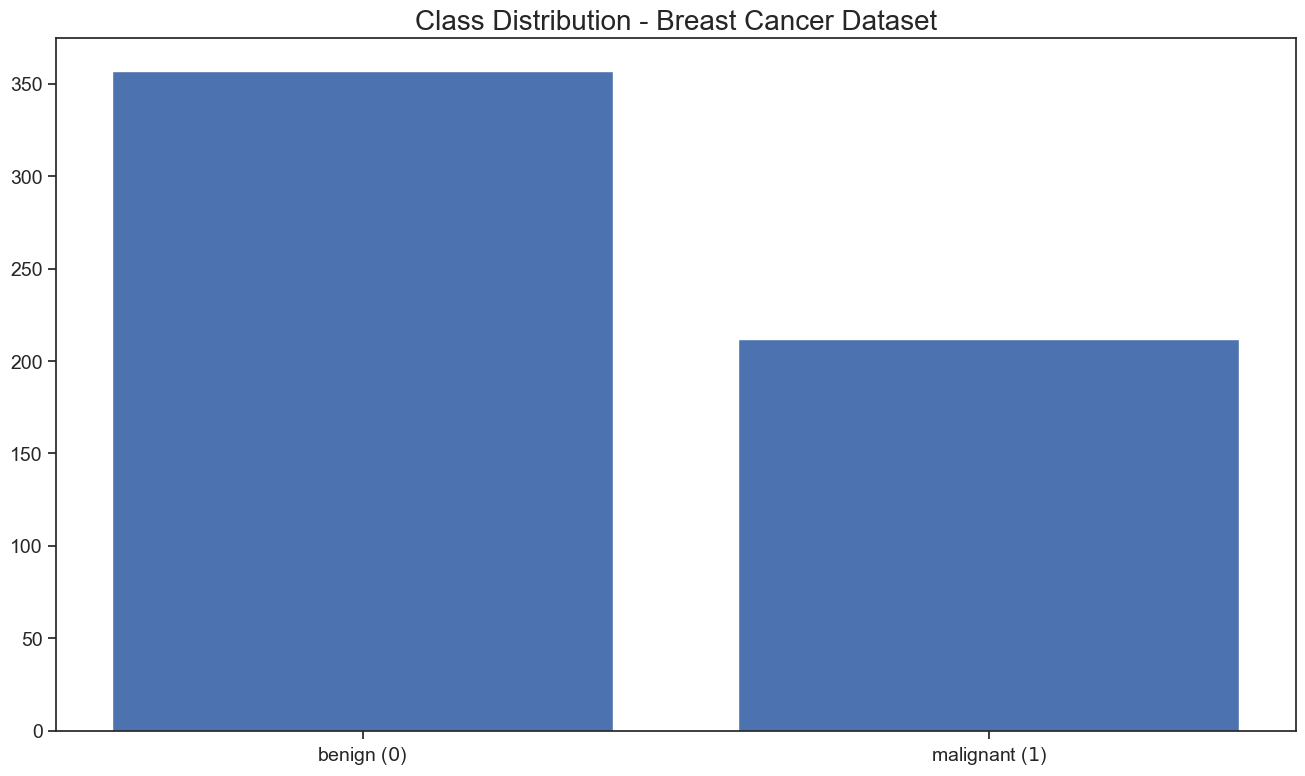

In [8]:
from utility.util import configure_plots

configure_plots()

classes, counts = np.unique(y, return_counts=True)

print(counts)
print(classes)

plt.bar(['benign ($0$)', 'malignant ($1$)'], counts)
plt.title('Class Distribution - Breast Cancer Dataset')

**Write-up!** What do you notice about the number of observations in each class? Could this potentially lead to problems for our modeling and evaluation? Think about how the data is divided for the various supervised ML phases.

_What I notice about the number of observations in each class is that the number of benign is almost double than malignant which shows an imbalanced dataset. When it comes to how data is divided for the various supervised ML phases, the imbalanced dataset could lead in trying to minimize error as the ML learning model could start training itself to predict only the benign cases when identifying the malignant cases are the more important identifications. _

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

Before we train any model, we split our data into two (or sometimes even more) subsets for training and testing. The [`train_test_split` 🔗](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function provided by Scikit-Learn has a keyword argument called `stratify`.

**Write-up!** What does the `stratify` argument do according to the function's documentation? Why do we use `stratify` when creating our training and testing sets for this dataset? How would our evaluation of the model be affected if we did not use stratify?

_According to the documention, the stratify argument splits the dataset into different train and test subsets that preserves the same proportion/class distribution as the original dataset. We use stratify when creating our training and testing sets for this dataset because if we don't we could end up with a disproportionate ratio (for example, if one has only a few malignant samples by random); stratify preserves the percentages presented by the original, full dataset we have. If we did not use stratify, the evaluation of the model could produce an unreliable result where the training set might be missing too many of the malignant cases, therefore, leading to learning poorly how to predict cancer._

<!-- END QUESTION -->

### Training the Logistic Regression Model

Now, you will train the classifier and then evaluate its performance. 

In the lab, we implemented Logistic Regression as described and formulated in class. In this series of problems, we will first review the model and practice building one with `sklearn`.

### Problem 1.4

First, we will begin by creating training and test sets with which we will build and evaluate our model with. Then, we will create a new instance of a `LogisticRegression` model and fit it with our training set. As we noticed in [Problem 1.3](#Problem-1.3), our dataset does not have a balanced class distribution. We will need to handle this accordingly.

**Do this!** In the following cell, you should do the following:
1. Create a train/test split with `train_test_split` with a `test_size` of 0.3, stratification by `y` with `stratify`, and a `random_state` of 4.
2. Create a new `LogisticRegression` model with the `'liblinear'` `solver`, set it's `random_state` to `4`, and `fit` it with the training set and stores it in `linear_model`.
3. Evaluate the performance by manually computing and printing the classification _accuracy_ of your trained model on the test set.

> **Hint**: Feel free to refer to any official documentation and remember that you can easily view the documentation in your notebook for any function or object by adding a `?` after its name (eg. `train_test_split?`).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state =4)
linear_model = LogisticRegression(solver = 'liblinear', random_state=4)
linear_model.fit(X_train, y_train)

accuracy = linear_model.score(X_test, y_test)
f'accuracy: {accuracy:0.2%}'

'accuracy: 90.64%'

In [10]:
grader.check("q1d")

q1d results: All test cases passed!

Looks pretty good!

## 2. Diving Deeper into Classification Error

While our model's accuracy was pretty good, let's analyze this accuracy more closely. For classification problems we can, instead of just counting mistakes, look at what kind of mistakes we made.

<!-- BEGIN QUESTION -->

### Problem 2.1

**Write-up!** What are the two different kinds of mistakes we can make for breast cancer diagnosis? Discuss them briefly.
> **Hint:** Answer this question in terms of the application; do **not** simply state the terms from the confusion matix. 

_The two different kind of mistakes we can make for breast cancer diagnosis is is inacurrately identifying in breast cancer diagnosis. One of them is giving a false positive where the outcome was identified as malignant, but it was actually benign. This can lead to the person undergoing risky and costly procedures they might have not needed because their breast cancer diagnosis predicted they had a malignant result for cancer instead of a benign diagnosis. The other mistake that could happen is where the breast cancer diagnosis gives a false negative where the diagnosis identitifes the outcome as benign, but it was actually malignant. This means that the cancer would not be correctly identified, therefore leading the cancer to spread and worsen._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Write-up!** Again, in the context of the application of classifying breast cancer tumors as either malignant or benign, should we care to distinguish between the two kinds of mistakes? Explain why or why not? 
If yes, is there one type of mistake we prefer over the other? If so, which one and why?

_I think when it comes to healthcare, minimizing error/mistakes is important. A valid argument could be offered for both types of mistakes; however, I would say inaccurately classifying the breast cancer tumors as benign (when they are actually malignant) is much more critical than inaccurately classifying the breast cancer tumors as malignant (when they are actually benign) because having the ability to catch cancer tumors in an earlier stage of its process is much more critical before the tumor starts to spread and worsen, making the recovery process in the later stages of cancer much more difficult. I consider preventing the malignant cancer tumors from spreading and worsening much more important than if someone is prescribed a few treatments even if the actual diagnosis should've been benign; identifying cancer early enough could offer more recovery possibilities, and an inaccurate diagnosis of an actual malignant result could lead to damaging health risks._

<!-- END QUESTION -->

### Confusion Matrices

A [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix), sometimes called an error matrix, helps us summarize and understand the performance of our classification models by presenting the different types of correct and incorrect predictions our model is making: true positives, true negatives, false positives, and false negatives.

<img src="utility/pics/confusion_matrix.png" alt="Drawing" style="width: 350px;"/>

<!-- BEGIN QUESTION -->

### Problem 2.2

**Do this!** In the following cell, use `confusion_matrix` from `sklearn.metrics` to compute the confusion matrix for the model you built in [Problem 1.4](#Problem-1.4). Then, use `plot_confusion_matrix` to visualize the matrix (you will need to specify the `labels` to use). 
> **Hint:** Remember that you can easily view the documentation for a function or object by adding a `?` after its name (e.g. `confusion_matrix?`) and feel free to refer to online documentation for help.

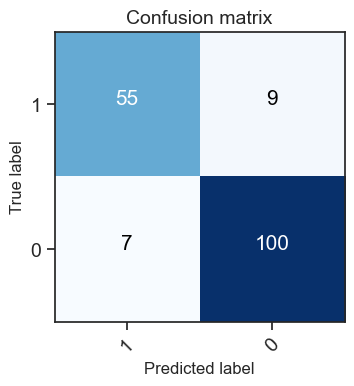

In [11]:
from sklearn.metrics import confusion_matrix
from utility.util import plot_confusion_matrix
# confusion_matrix?

matrix = confusion_matrix(y_test, linear_model.predict(X_test))

plot_confusion_matrix(matrix, labels = [1, 0])

In [12]:
grader.check("q2bii")

q2bii results: All test cases passed!

<!-- END QUESTION -->

### Experiment: Making Decisions

Now, let's take a look at decision boundaries. As we mentioned in both lecture and lab, label predictions (eg. $\hat{y} = 1$) are made by considering the class probabilities $P(y = 1 \mid x)$ produced by our model with a decision threshold. Typically, we use a threshold of 0.5 such that $\hat{y} = 1$ if $P(y = 1 \mid x) > 0.5$. However, as we hinted in [Problem 2.1](#Problem-2.1), there are situations and contexts in which the cost of making a _false positive_ error is different than making a _false negative_ error. We can account for cost differences by adjusting the threshold, and therefore the decision boundary, of our classifier.

In the following few cells, we will prepare an experiment to test and observe the effects of changing the decision threshold of our classification model.

### Problem 2.3

The first thing we will need to prepare is a way to compute the predictions of a model given a threshold. This is because `sklearn` does not offer an option to do this.

**Do this!** Complete the `make_predictions` function so that it computes the predicted labels `y_pred` $\in [0, 1]$ for data `X_test` with a given `model` and decision `threshold`. 
> **Hint:** You may find the `model.predict_proba` method and [this StackOverflow thread](https://stackoverflow.com/questions/30820962/splitting-columns-of-a-numpy-array-easily) to be helpful.

In [13]:
def make_predictions(model, X_test, threshold=0.5):
    '''
    Computes the predicted labels for points in X_TEST using a given MODEL and THRESHOLD
    '''
    
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= threshold).astype(int)
    
    return y_pred

In [14]:
grader.check("q2c")

q2c results: All test cases passed!

<!-- BEGIN QUESTION -->

### Problem 2.4

Next, we will combine all of the things we have done in earlier problems into a single function that produces a confusion matrix plot by fitting and evaluating new Logisitic Regression models with varying thresholds. Note that there will be some redundancy/inefficiency in this function because it repeatedly recomputes the same values, but it is okay as it simplifies the code.

**Do this!** Complete the `boundary_experiment` function so that it does the following:
1. Creates a train/test split with `train_test_split` with a `test_size` of 0.3, stratification by `y` with `stratify`, and a `random_state` of 11.
2. Creates a new `LogisticRegression` model with the `'liblinear'` `solver`, set it's `random_state` to `4`, and `fit` it with the training set.
3. Makes predictions `y_pred` for test set points using `make_predictions` and `threshold`.
4. Computes a confusion matrix, but instead of getting FP, FN, TP, and TN, we want the false positive rate (FPR), false negative rate (FNR), true positive rate (TPR), and true negative rate (TNR). This will help in decision making since the classes in our dataset are unbalanced.  **Hint:** provide `normalize='true'` as an argument. 
5. Plots the confusion matrix using `plot_confusion_matrix`.

> **Hint:** Feel free to refer to any official documentation and remember that you can easily view the documentation for a function or object by adding a `?` after its name (eg. `plot_confusion_matrix?`).

In [15]:
def boundary_experiment(X, y, threshold=0.5):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 11)
    linear_model = LogisticRegression(solver = 'liblinear', random_state = 4)
    linear_model.fit(X_train, y_train)

    y_pred = make_predictions(linear_model, X_test, threshold)

    matrix = confusion_matrix(y_test, y_pred, normalize = 'true')
    plot_confusion_matrix(matrix, labels = [1, 0])


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Problem 2.5

In this problem, we will experiment with how changing the decision boundary (threshold) affects the confusion matrix using the functions that you implemented earlier. In order to make the visualization work we need the `ipywidgets` package. Let's check if it is installed. 

In [16]:
! pip show ipywidgets
## the following commands are for debugging purposes
#! pip show notebook
#! pip show widgetsnbextension
#! jupyter nbextension enable --py widgetsnbextension

Name: ipywidgets
Version: 8.1.5
Summary: Jupyter interactive widgets
Home-page: http://jupyter.org
Author: Jupyter Development Team
Author-email: jupyter@googlegroups.com
License: BSD 3-Clause License
Location: /opt/anaconda3/envs/cse217a/lib/python3.10/site-packages
Requires: comm, ipython, jupyterlab-widgets, traitlets, widgetsnbextension
Required-by: jupyter


If the above contains a version number greater than 8.1, move to **Do this!**. 

Otherwise, if the cell above contains a version number less than 8.1, then uncomment and run this command below `! pip install --upgrade ipywidgets` to upgrade the ``ipywidgets`` package.

If the cell above does not contain a version number, then uncomment and run this command below `! pip install ipywidgets` to install the ``ipywidgets`` package.

In [17]:
# ! pip install ipywidgets

In [18]:
# ! pip install --upgrade ipywidgets

**Do this!** Evaluate the following cell and experiment with the slider.

> If you get an error message or don't see a slider when running the cell below, then this is the fix:
> 1. open the terminal and activate your cse217a conda environment
> 2. (with the conda environment activated) run the following command first: `conda install notebook==6.4.5`
> 3. then, (with the conda environment still activated) run the following command `pip install --upgrade notebook`

In [19]:
from ipywidgets import interactive, fixed

interactive(boundary_experiment, X=fixed(X), y=fixed(y), threshold=(0, 1, 0.01))

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.01), Output()), _dom_cla…

**Write-up!** How does changing the threshold affect the confusion matrix (e.g. correct classification rates and error rates)?

_Changing the threshold affects the confusion matrix as when the threshold decreases, the true positives and false positives (TP & FP) increase, and the false and true negatives (FN & TN) decrease. A similar pattern is exhibited when the threshold is raised where false and true negatives (FN & TN) are increased whilst the true and false positives (TP & FP) are decreased. This means that as we lower the threshold, more samples are becoming easier to identify as malignant, and more actual benign cases are misclassified as malignant. As we increase the threshold, this means that it has become harder for the samples to identify as malignant. FP decreases as there are less benign cases misclassified as malignant. TP decreases as malignant cancer tumors are less correctly identified. TN increase as more of the cases are identified as benign, but also, there is an increase in FN too which means there is an increase in misclassification for malignant cases where they are not identified._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Write-up!** What is the smallest threshold, if any, that eliminates false positive errors? What is the largest threshold, if any, that eliminates false negative errors? Which of the two scenarios would be preferable, if any?

_The smallest threshold that eliminates false positive errors is if the threshold is increased to the 0.87, and the largest threshold that elimates false negative errors would be 0.04. If we had to choose and depending on context, eliminating false negatives (identifying tumors as benign when they are actually benign) is preferable since missing a malignant tumor can be far more harmful than mistakenly identifying a benign tumor as malignant; there are much more serious health consequences on missing malignant cancer tumors._

<!-- END QUESTION -->

**That's it! Follow the submission instructions below:**
* Restart your kernel and run all the cells
* Save your notebook
* Upload the .ipynb notebook directly to Gradescope